In [1]:
%load_ext autoreload

In [2]:
%autoreload 1

In [3]:
import os, re, sys
import numpy as np
from rich import print
from rich.pretty import pprint
from rich.progress import track
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib.backends.backend_pdf import PdfPages
import hist
from hist import Hist
import mplhep as hep
import uproot
from rich.progress import Progress

parent_dir = os.path.dirname(os.path.abspath(""))
sys.path.append(parent_dir)

import cms_styles

%aimport plot_utils

In [4]:
mpl.rcParams.update({"figure.max_open_warning": 0})
hep.style.use("CMS")
np.set_printoptions(suppress=True)

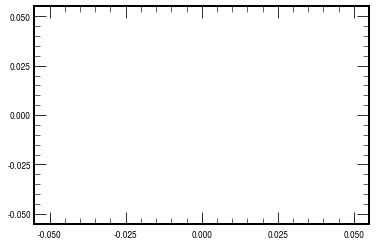

In [5]:
plt.plot()
hep.style.use(hep.style.CMS)
mpl.rcParams["figure.facecolor"] = "white"
plt.style.use(cms_styles.CMS_petroff_10)

In [6]:
def merge_runs(plots, run):
    names = [
        "Higgs",
        "TTV",
        "ST_NLO",
        "WJets",
        "VV+VVV",
        "TT_powheg",
        "DY",
        "QCD_Pt_MuEnrichedPt5",
        "total_bkg",
    ]
    # Add signal processes
    signal_processes = list(
        set(p[:-5] for p in plots.keys() if re.search("GluGluToSUEP.*13TeV", p))
    )
    # Remove 2016APV for now
    # years = ["2016APV", "2016", "2017", "2018"]
    years = ["2016", "2017", "2018"]
    if run == "Run3":
        names.remove("TTV")
        names.remove("ST_NLO")
        years = ["2022", "2022EE", "2023", "2023BPix"]
        # Add signal processes
        signal_processes = list(
            set(p[:-5] for p in plots.keys() if re.search("GluGluToSUEP.*13p6TeV", p))
        )
    names.append("Data")
    names.extend(signal_processes)
    run_plots = {}
    for name in names:
        run_plots[f"{name}_{run}"] = {}
        for year in years:
            if f"{name}_{year}" not in plots.keys():
                continue
            for plot in plots[f"{name}_{year}"]:
                if plot not in run_plots[f"{name}_{run}"].keys():
                    run_plots[f"{name}_{run}"][plot] = plots[f"{name}_{year}"][
                        plot
                    ].copy()
                else:
                    run_plots[f"{name}_{run}"][plot] += plots[f"{name}_{year}"][plot]
    return run_plots

In [9]:
plots = {}
years_to_load = [
    # "2016APV",
    # "2016",
    # "2017",
    "2018",
    # "2022",
    # "2022EE",
    # "2023",
    # "2023BPix",
]
for year in track(years_to_load, description="Loading plots"):
    plots = plots | plot_utils.loader(
        tag=f"error_cuts_Jun2025_{year}",
        era=year,
        load_data=True,
    )
# run2_plots = merge_runs(plots, "Run2")
# plots = plots | run2_plots
# run3_plots = merge_runs(plots, "Run3")
# plots = plots | run3_plots

Loading plots ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00
Loading plots ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00

In [24]:
for axis in plots["total_bkg_2018"]["CR_prompt"].axes:
    print(axis.name, axis.edges)

prompt dxyErr cut [0.0005    0.0008125 0.001125  0.0014375 0.00175   0.0020625 0.002375
 0.0026875 0.003    ]

prompt dzErr cut [0.0008 0.0014 0.002  0.0026 0.0032 0.0038 0.0044 0.005 ]

qcd dxyErr cut [0.0007     0.00117143 0.00164286 0.00211429 0.00258571 0.00305714
 0.00352857 0.004     ]

qcd dzErr cut [0.001 0.002 0.003 0.004 0.005]

nMuon [2. 3. 4. 5. 6.]

In [35]:
for axis in plots["total_bkg_2018"]["CR_cb"].axes:
    print(axis.name, axis.edges)

dxyErr cut [0.0006     0.00108889 0.00157778 0.00206667 0.00255556 0.00304444
 0.00353333 0.00402222 0.00451111 0.005     ]

dzErr cut [0.0007    0.0012375 0.001775  0.0023125 0.00285   0.0033875 0.003925
 0.0044625 0.005    ]

nMuon [1. 2. 3. 4. 5.]

In [45]:
plots[f"Data_2018"][f"CR_{region}"].axes[0].edges

array([0.0005   , 0.0008125, 0.001125 , 0.0014375, 0.00175  , 0.0020625,
       0.002375 , 0.0026875, 0.003    ])

In [44]:
plots[f"Data_2018"][f"CR_{region}"].axes[0].centers

array([0.00065625, 0.00096875, 0.00128125, 0.00159375, 0.00190625,
       0.00221875, 0.00253125, 0.00284375])

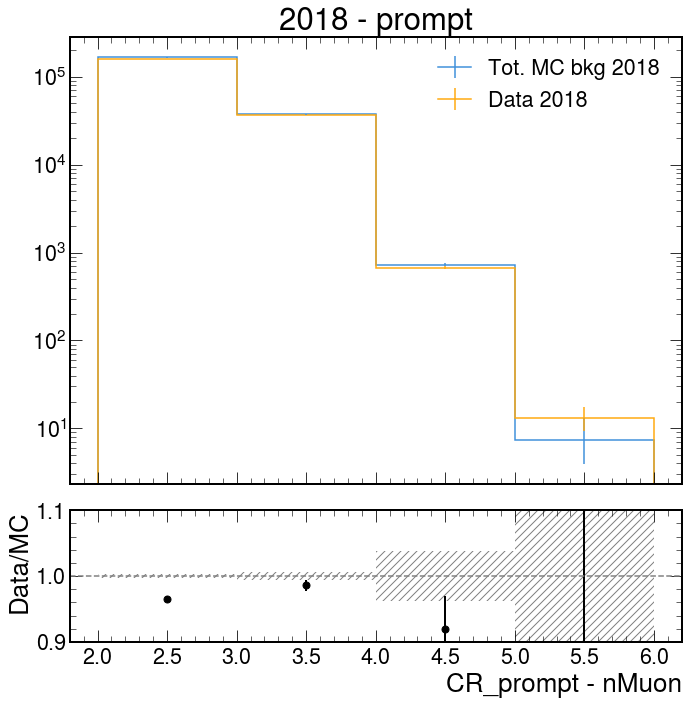

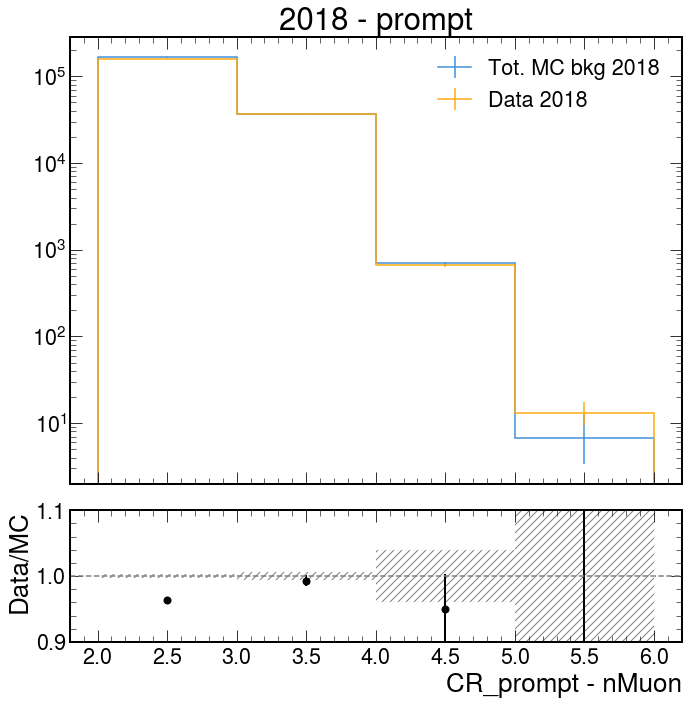

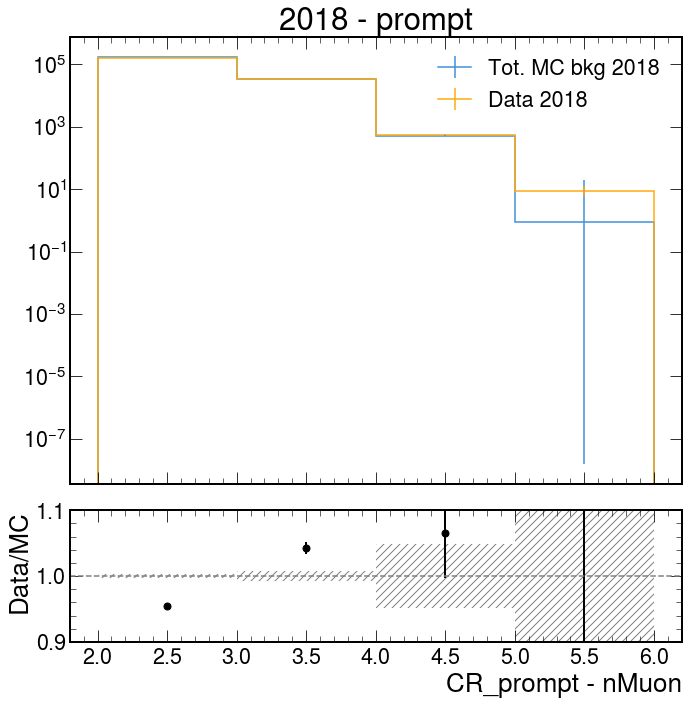

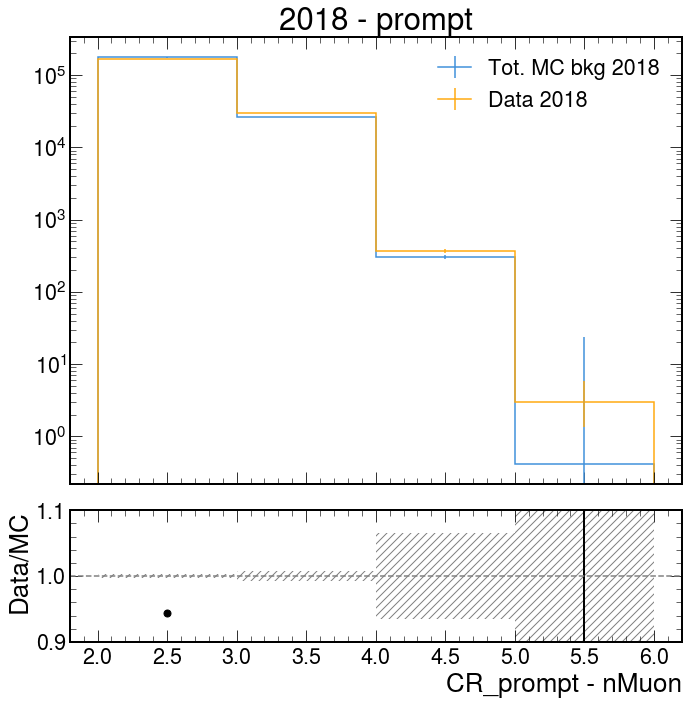

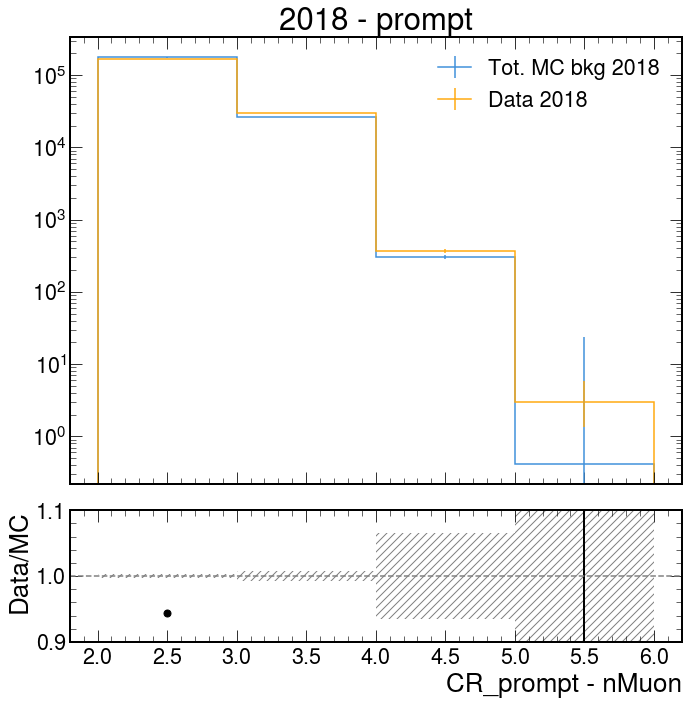

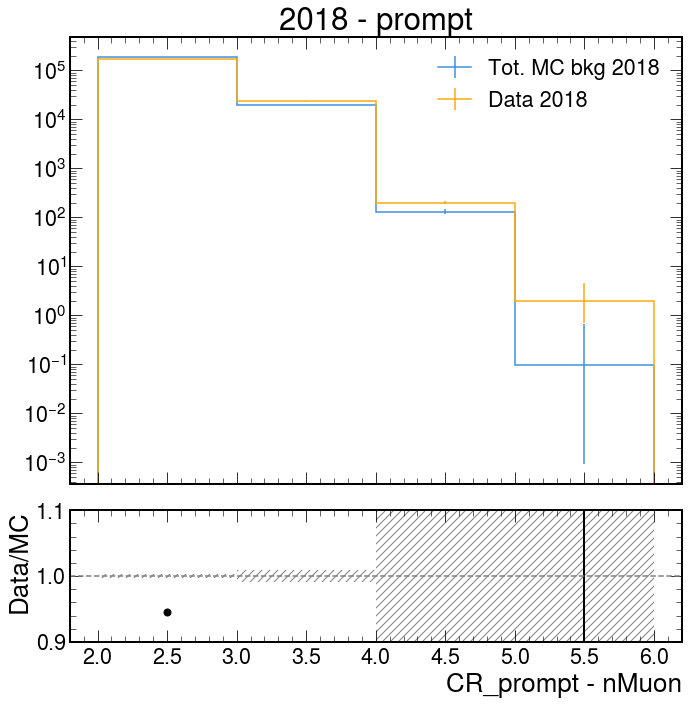

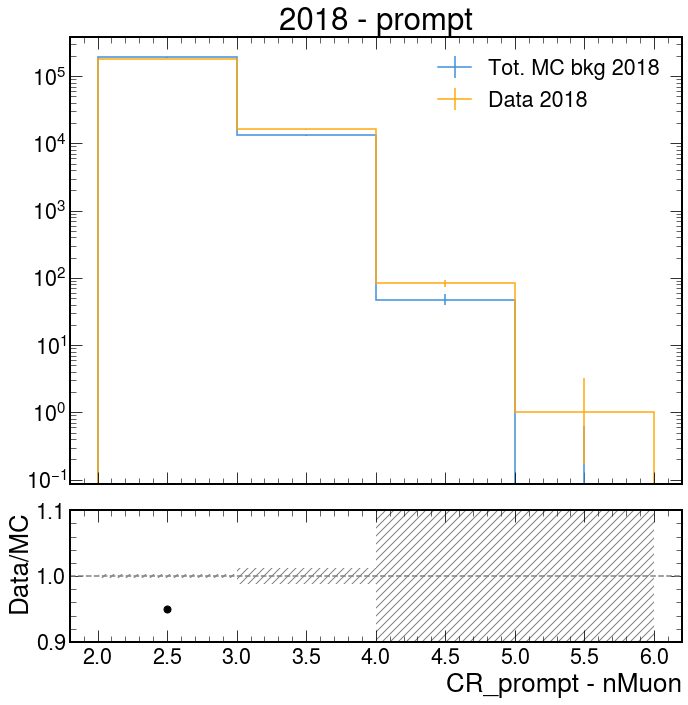

/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/tmp/ipykernel_3998056/1924352565.py:50: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3998056/1924352565.py:50: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3998056/1924352565.py:51: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/

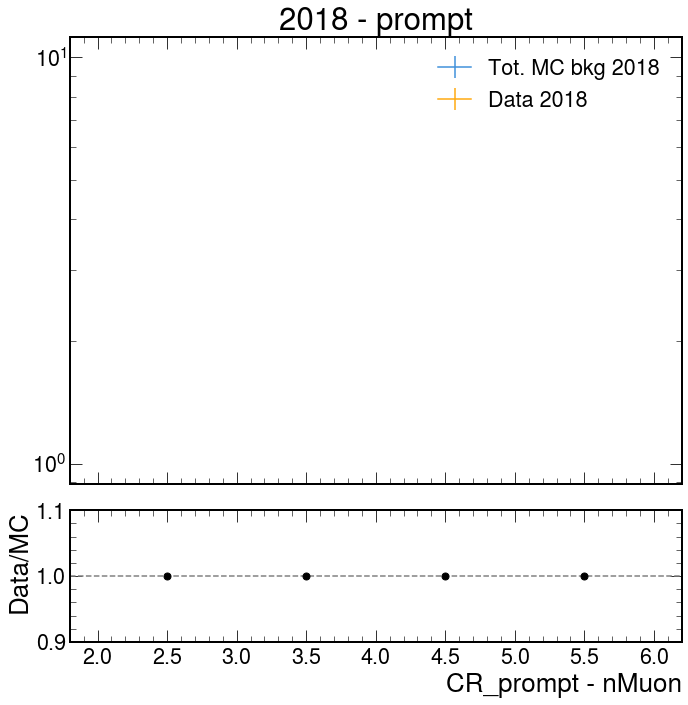

In [34]:
region = "prompt"
era = "2018"

# for dxyErr_cut in plots[f"Data_{era}"][f"CR_{region}"].axes[0].centers:
#     hist_data = plots[f"Data_{era}"][f"CR_{region}"][dxyErr_cut * 1j, 0.0008j, 0.0007j, 0.001j, :]
#     hist_bkg_total = plots[f"total_bkg_{era}"][f"CR_{region}"][dxyErr_cut * 1j, 0.0008j, 0.0007j, 0.001j, :]

# for dzErr_cut in plots[f"Data_{era}"][f"CR_{region}"].axes[1].centers:
#     hist_data = plots[f"Data_{era}"][f"CR_{region}"][0.0005j, dzErr_cut * 1j, 0.0007j, 0.001j, :]
#     hist_bkg_total = plots[f"total_bkg_{era}"][f"CR_{region}"][0.0005j, dzErr_cut * 1j, 0.0007j, 0.001j, :]

# for dxyErr_cut in plots[f"Data_{era}"][f"CR_{region}"].axes[2].centers:
#     hist_data = plots[f"Data_{era}"][f"CR_{region}"][0.0005j, 0.0008j, dxyErr_cut * 1j, 0.001j, :]
#     hist_bkg_total = plots[f"total_bkg_{era}"][f"CR_{region}"][0.0005j, 0.0008j, dxyErr_cut * 1j, 0.001j, :]

# for dzErr_cut in plots[f"Data_{era}"][f"CR_{region}"].axes[3].centers:
#     hist_data = plots[f"Data_{era}"][f"CR_{region}"][0.0005j, 0.0008j, 0.0007j, dzErr_cut * 1j, :]
#     hist_bkg_total = plots[f"total_bkg_{era}"][f"CR_{region}"][0.0005j, 0.0008j, 0.0007j, dzErr_cut * 1j, :]

for dxyErr_cut in plots[f"Data_{era}"][f"CR_{region}"].axes[2].centers:
    hist_data = plots[f"Data_{era}"][f"CR_{region}"][
        0.0005j, 0.0008j, dxyErr_cut * 1j, 0.003j, :
    ]
    hist_bkg_total = plots[f"total_bkg_{era}"][f"CR_{region}"][
        0.0005j, 0.0008j, dxyErr_cut * 1j, 0.003j, :
    ]

    # Normalize
    # normalization = hist_data.sum().value / hist_bkg_total.sum().value
    # hist_bkg_total = hist_bkg_total * normalization

    fig = plt.figure(figsize=(10, 10))
    plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
    ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
    ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

    hist_bkg_total.plot(label=f"Tot. MC bkg {era}", ax=ax1)
    hist_data.plot(label=f"Data {era}", ax=ax1)

    x_hatch = np.vstack(
        (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
    ).reshape((-1,), order="F")

    ratio = np.divide(
        hist_data.values(),
        hist_bkg_total.values(),
        out=np.ones_like(hist_data.values()),
        where=hist_bkg_total.values() != 0,
    )
    ratio_err = np.where(
        hist_bkg_total.values() > 0,
        np.sqrt(
            (hist_bkg_total.values() ** -2) * (hist_data.variances())
            + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
            * (hist_bkg_total.variances())
        ),
        0,
    )
    ax2.errorbar(
        hist_data.axes.centers[0],
        ratio,
        yerr=ratio_err,
        color="black",
        fmt="o",
        linestyle="none",
        markersize=7,
        lw=2,
    )

    # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
    mc_rel_unc = np.divide(
        np.sqrt(hist_bkg_total.variances()),
        hist_bkg_total.values(),
        out=np.zeros_like(hist_bkg_total.values()),
        where=hist_bkg_total.values() != 0,
    )
    y_hatch2 = np.vstack(
        (np.ones_like(hist_bkg_total.values()), np.ones_like(hist_bkg_total.values()))
    ).reshape((-1,), order="F")
    y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape((-1,), order="F")
    ax2.fill_between(
        x=x_hatch,
        y1=y_hatch2 - y_hatch2_unc,
        y2=y_hatch2 + y_hatch2_unc,
        step="pre",
        facecolor="none",
        edgecolor=(0, 0, 0, 0.5),
        linewidth=0,
        hatch="///",
    )
    ax2.axhline(1, ls="--", color="gray")

    plt.sca(ax2)
    plt.xlabel(f"CR_{region} - nMuon")
    ax1.set_yscale("log")
    plt.ylim(0.9, 1.1)
    plt.ylabel("Data/MC")
    plt.setp(ax1.get_xticklabels(), visible=False)
    ax1.set_xlabel("", visible=False)
    ax1.set_title(f"{era} - {region}")
    ax1.legend()
    plt.show()

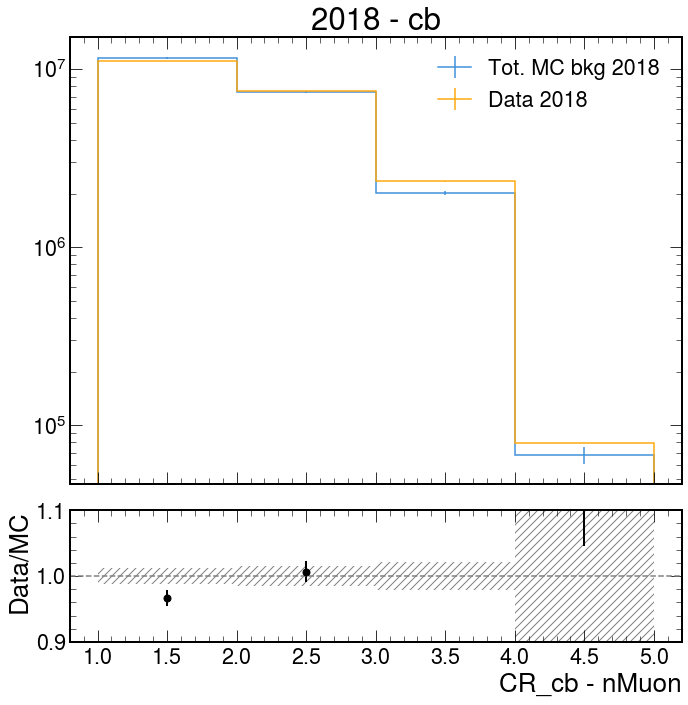

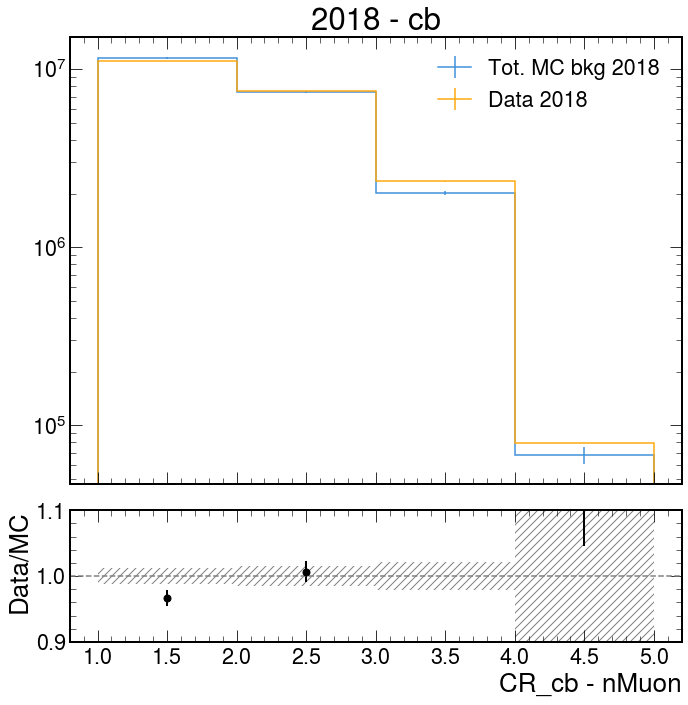

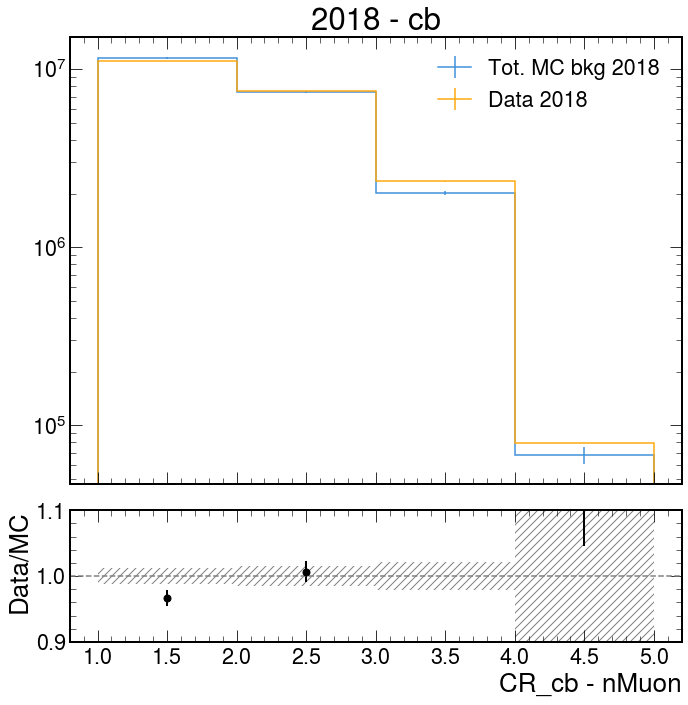

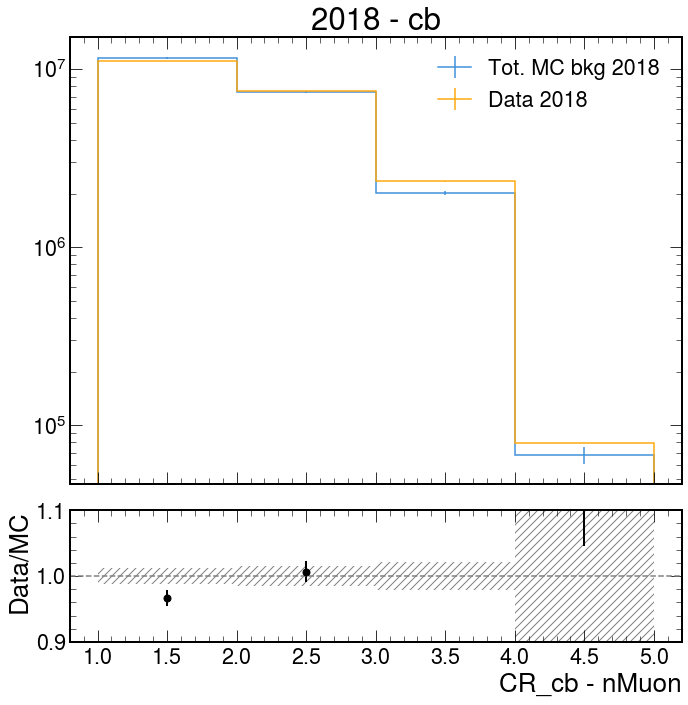

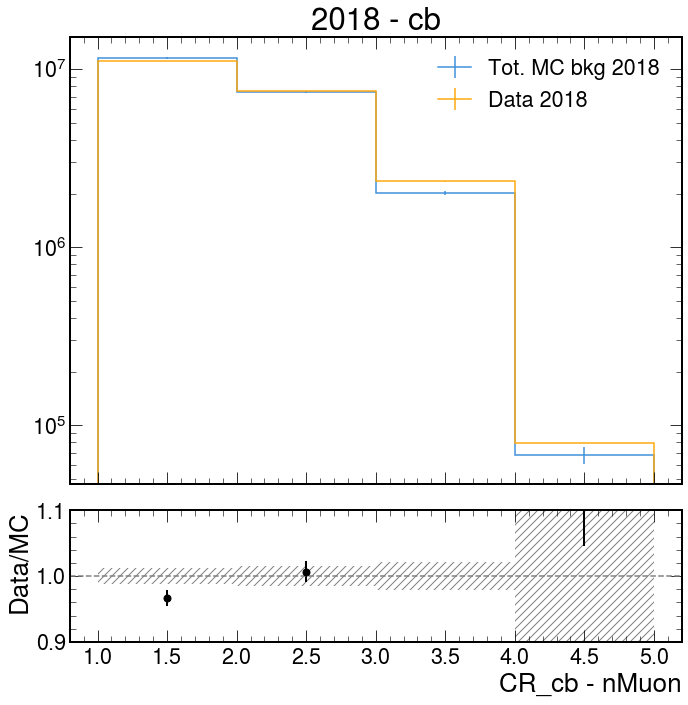

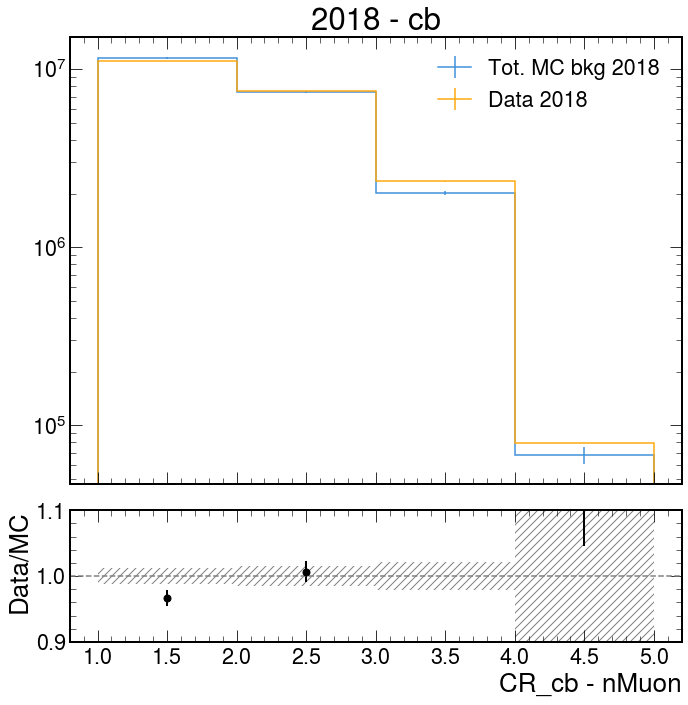

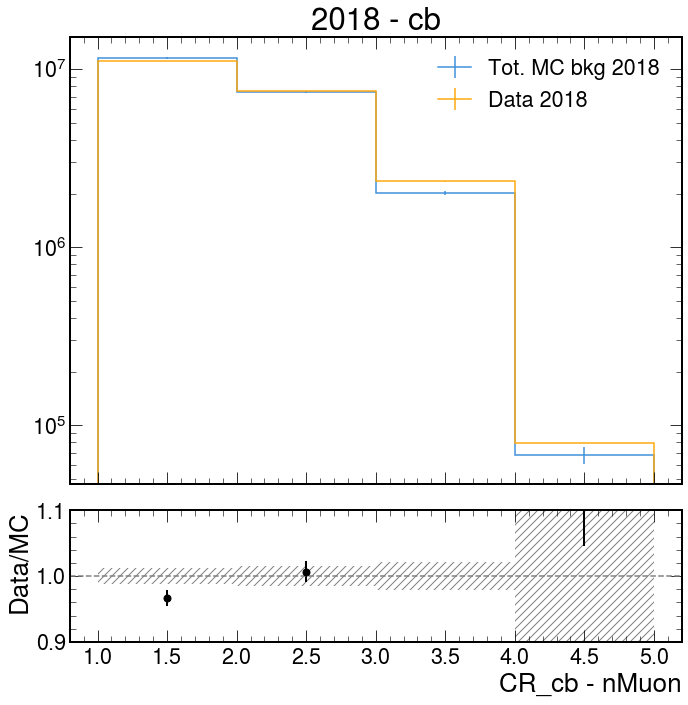

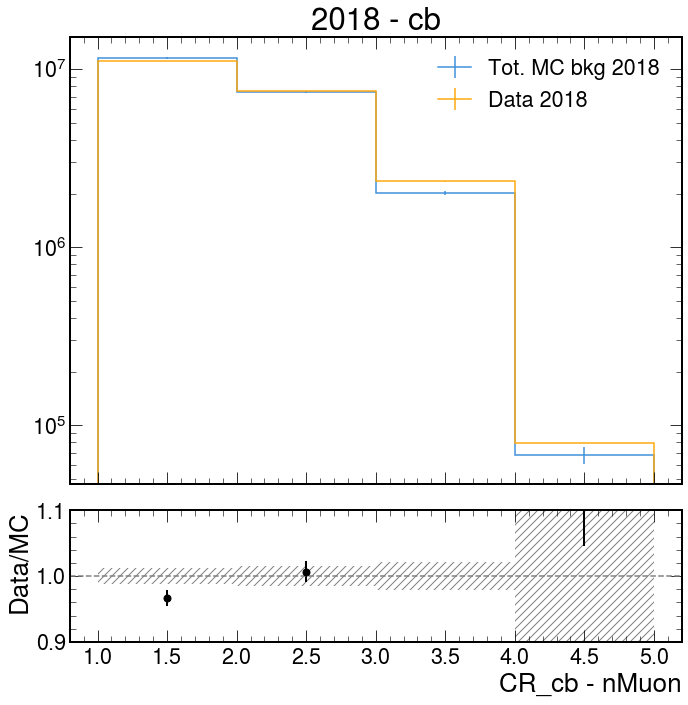

In [51]:
region = "cb"
era = "2018"

# for dxyErr_cut in plots[f"Data_{era}"][f"CR_{region}"].axes[0].centers:
#     hist_data = plots[f"Data_{era}"][f"CR_{region}"][dxyErr_cut * 1j, 0.0007j, :]
#     hist_bkg_total = plots[f"total_bkg_{era}"][f"CR_{region}"][dxyErr_cut * 1j, 0.0007j, :]

for dzErr_cut in plots[f"Data_{era}"][f"CR_{region}"].axes[1].centers:
    hist_data = plots[f"Data_{era}"][f"CR_{region}"][0.0006j, dzErr_cut * 1j, :]
    hist_bkg_total = plots[f"total_bkg_{era}"][f"CR_{region}"][
        0.0006j, dzErr_cut * 1j, :
    ]

    # Normalize
    normalization = hist_data.sum().value / hist_bkg_total.sum().value
    hist_bkg_total = hist_bkg_total * normalization

    fig = plt.figure(figsize=(10, 10))
    plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
    ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
    ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

    hist_bkg_total.plot(label=f"Tot. MC bkg {era}", ax=ax1)
    hist_data.plot(label=f"Data {era}", ax=ax1)

    x_hatch = np.vstack(
        (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
    ).reshape((-1,), order="F")

    ratio = np.divide(
        hist_data.values(),
        hist_bkg_total.values(),
        out=np.ones_like(hist_data.values()),
        where=hist_bkg_total.values() != 0,
    )
    ratio_err = np.where(
        hist_bkg_total.values() > 0,
        np.sqrt(
            (hist_bkg_total.values() ** -2) * (hist_data.variances())
            + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
            * (hist_bkg_total.variances())
        ),
        0,
    )
    ax2.errorbar(
        hist_data.axes.centers[0],
        ratio,
        yerr=ratio_err,
        color="black",
        fmt="o",
        linestyle="none",
        markersize=7,
        lw=2,
    )

    # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
    mc_rel_unc = np.divide(
        np.sqrt(hist_bkg_total.variances()),
        hist_bkg_total.values(),
        out=np.zeros_like(hist_bkg_total.values()),
        where=hist_bkg_total.values() != 0,
    )
    y_hatch2 = np.vstack(
        (np.ones_like(hist_bkg_total.values()), np.ones_like(hist_bkg_total.values()))
    ).reshape((-1,), order="F")
    y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape((-1,), order="F")
    ax2.fill_between(
        x=x_hatch,
        y1=y_hatch2 - y_hatch2_unc,
        y2=y_hatch2 + y_hatch2_unc,
        step="pre",
        facecolor="none",
        edgecolor=(0, 0, 0, 0.5),
        linewidth=0,
        hatch="///",
    )
    ax2.axhline(1, ls="--", color="gray")

    plt.sca(ax2)
    plt.xlabel(f"CR_{region} - nMuon")
    ax1.set_yscale("log")
    plt.ylim(0.9, 1.1)
    plt.ylabel("Data/MC")
    plt.setp(ax1.get_xticklabels(), visible=False)
    ax1.set_xlabel("", visible=False)
    ax1.set_title(f"{era} - {region}")
    ax1.legend()
    plt.show()